Garis besar Ide:
Jadi nnti di app, kita bakal bagi 5
EDA
Preprocessing
Train model
Model evaluation
Demo model

link referensi yt: https://www.youtube.com/watch?v=o4d9lsinqQQ

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns


In [71]:
df = pd.read_excel("Concrete_Data.xls")
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [72]:
df.dtypes

Cement (component 1)(kg in a m^3 mixture)                float64
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    float64
Fly Ash (component 3)(kg in a m^3 mixture)               float64
Water  (component 4)(kg in a m^3 mixture)                float64
Superplasticizer (component 5)(kg in a m^3 mixture)      float64
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     float64
Fine Aggregate (component 7)(kg in a m^3 mixture)        float64
Age (day)                                                  int64
Concrete compressive strength(MPa, megapascals)          float64
dtype: object

Dari sini itu start EDA.
Pertama kalian itu nampilin bagian df.head, df.describe sama df.dtypes. Sama kalau bisa kasi opsi check null datam trs tampilin df.isnull.sum

In [73]:
df.isnull().sum()

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64

In [74]:
df.describe()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [75]:
features = list(df.select_dtypes(include=["float64", "Int64"]).columns)
features.remove("Concrete compressive strength(MPa, megapascals) ")
print(features)


['Cement (component 1)(kg in a m^3 mixture)', 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)', 'Fly Ash (component 3)(kg in a m^3 mixture)', 'Water  (component 4)(kg in a m^3 mixture)', 'Superplasticizer (component 5)(kg in a m^3 mixture)', 'Coarse Aggregate  (component 6)(kg in a m^3 mixture)', 'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)']


Ini bagian Visualisasi EDA
Nanti kalian kasi pilihan mereka mau nampilin apa aja
Histogram, heatmap, scatterplot sama boxplot

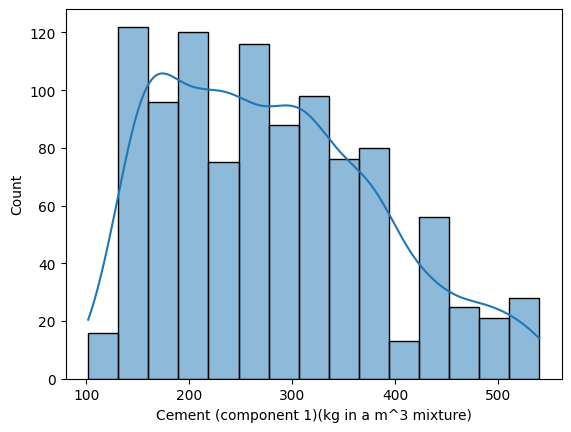

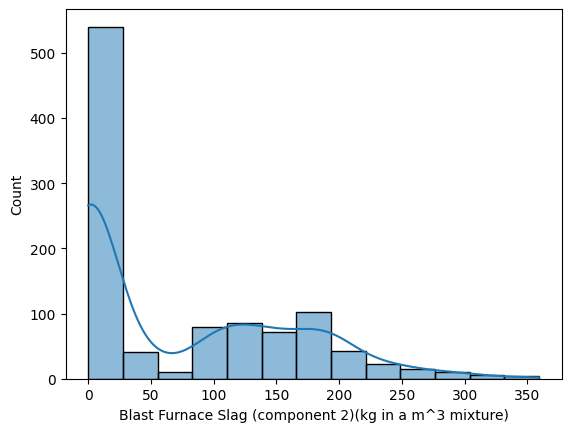

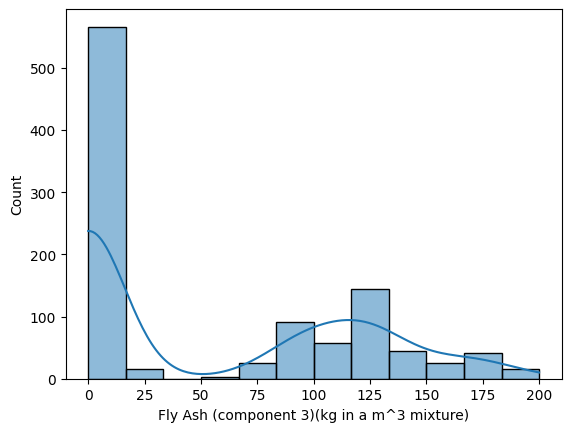

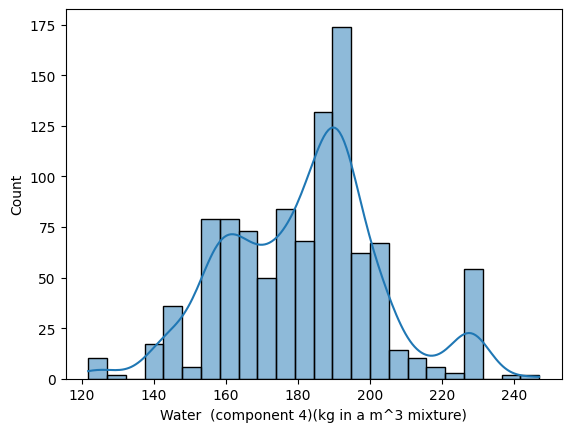

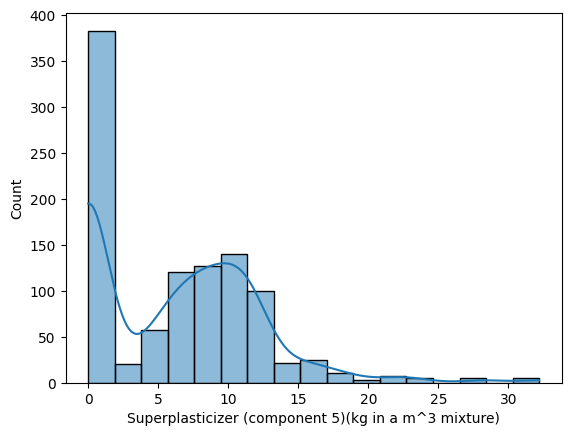

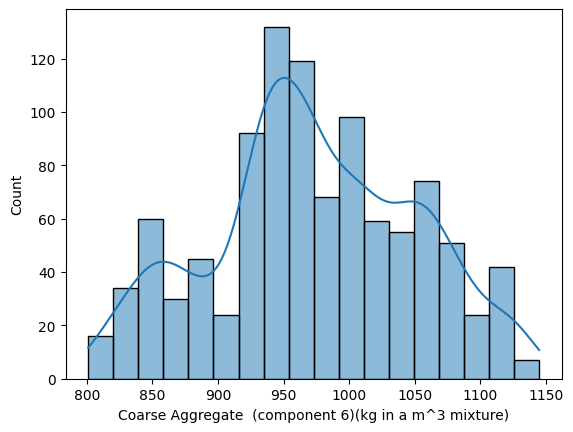

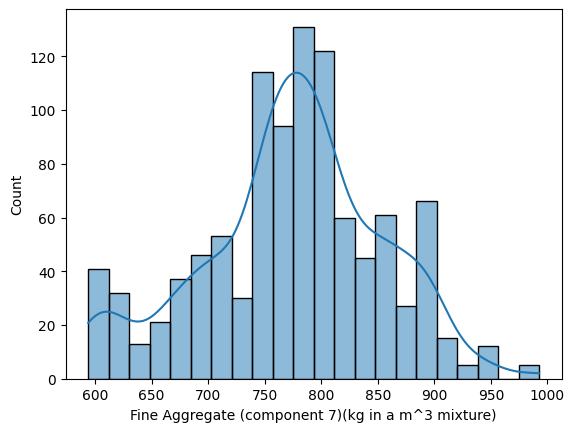

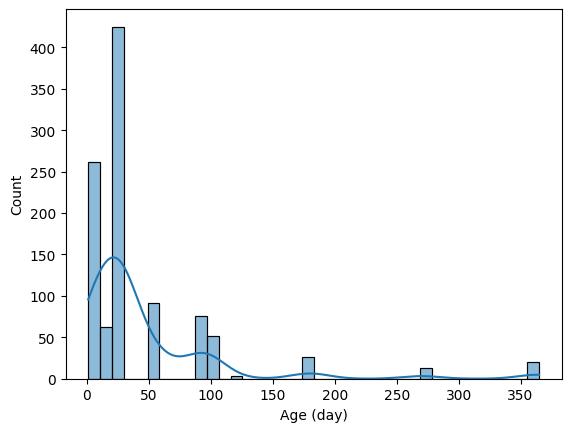

In [76]:
for col in features:
    sns.histplot(df[col], kde=True)
    plt.show()

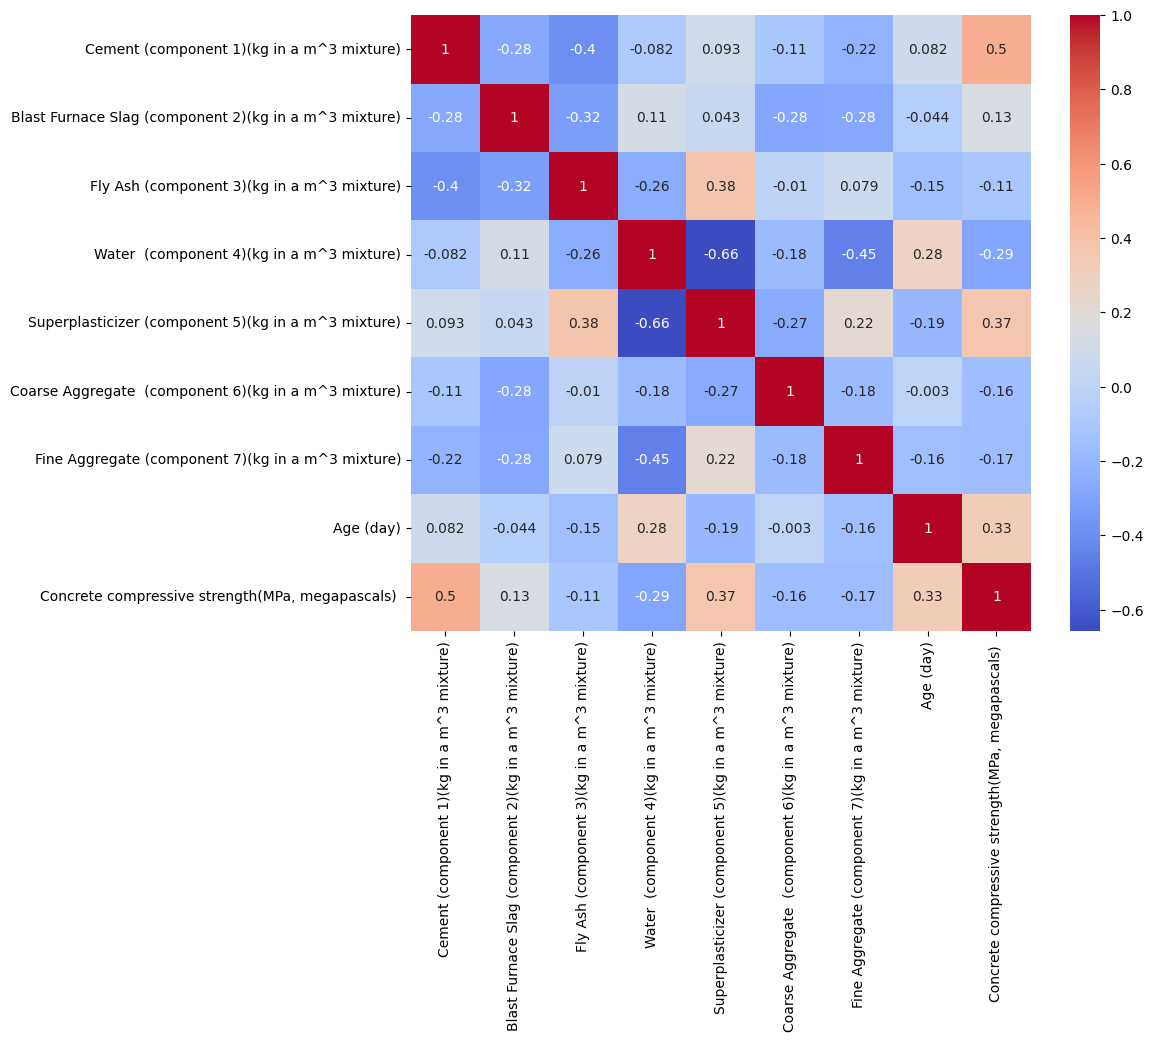

In [77]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

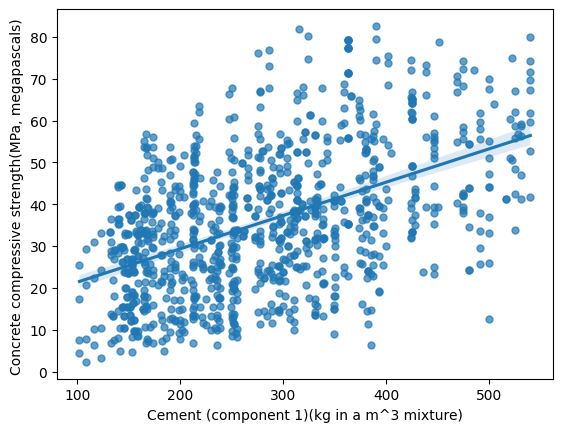

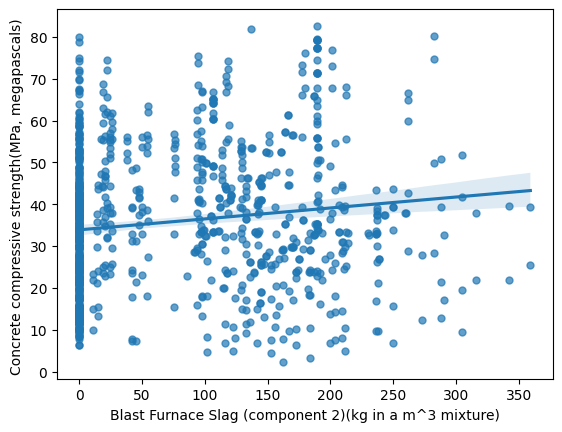

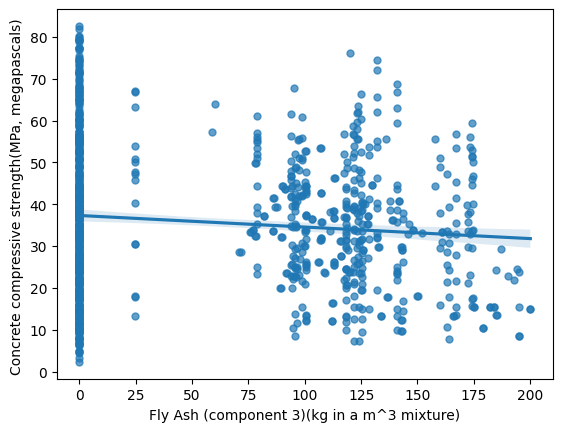

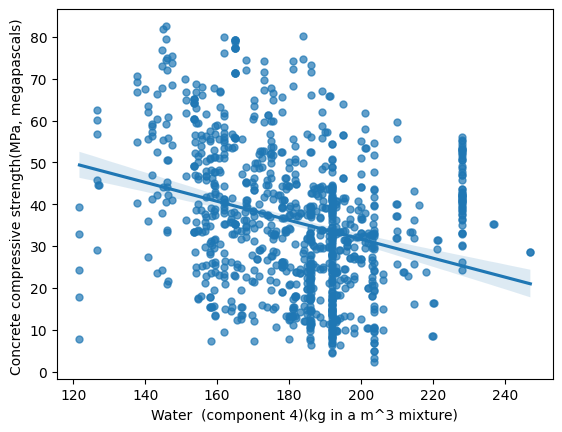

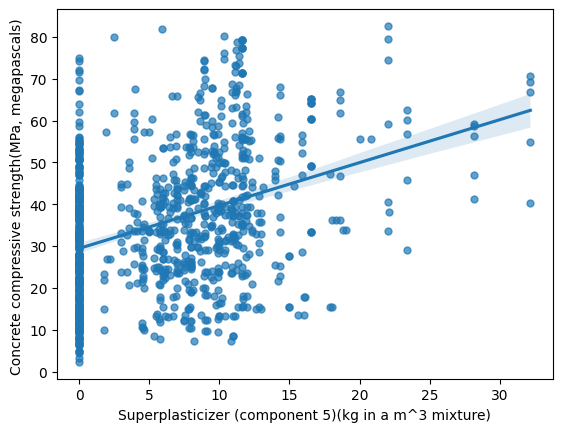

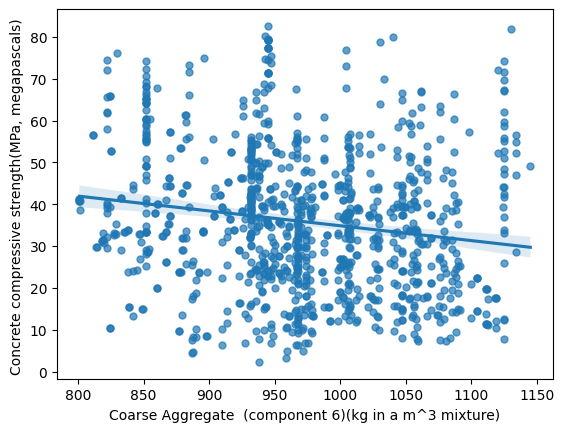

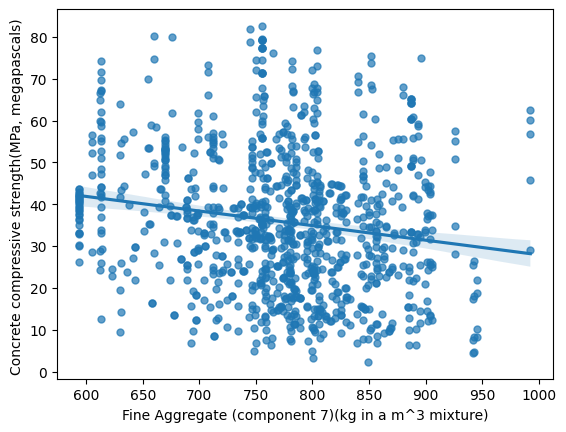

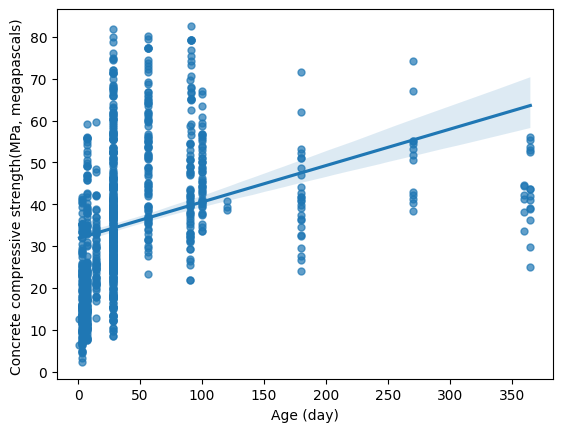

In [78]:
for col in features:
    plt.ylabel("strength(MPA)")
    sns.regplot(x = df[col], y = df["Concrete compressive strength(MPa, megapascals) "],  scatter_kws={"alpha": 0.7, "s": 25})
    plt.show()


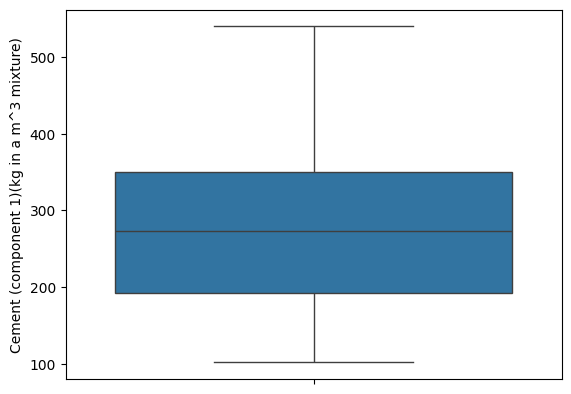

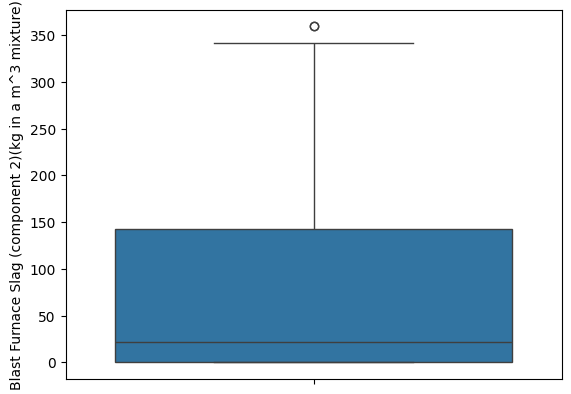

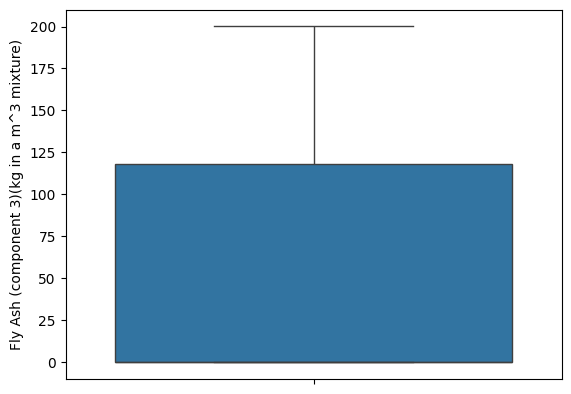

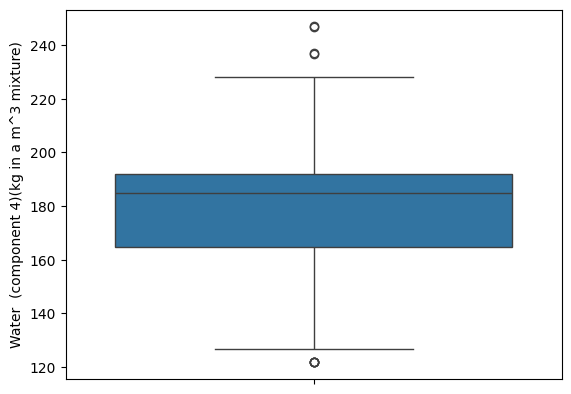

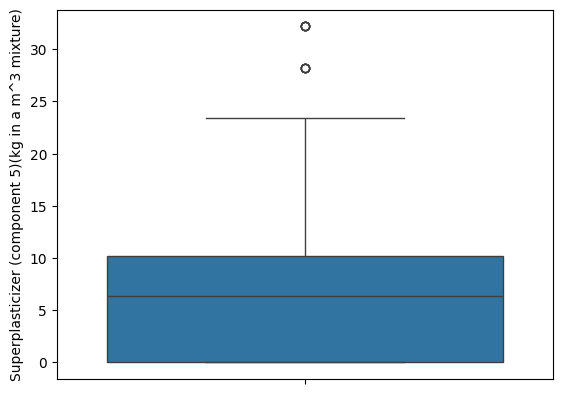

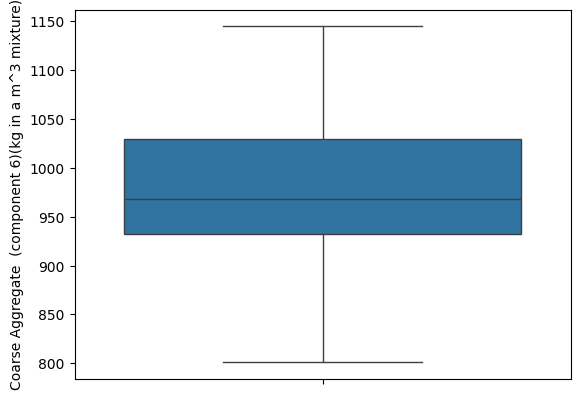

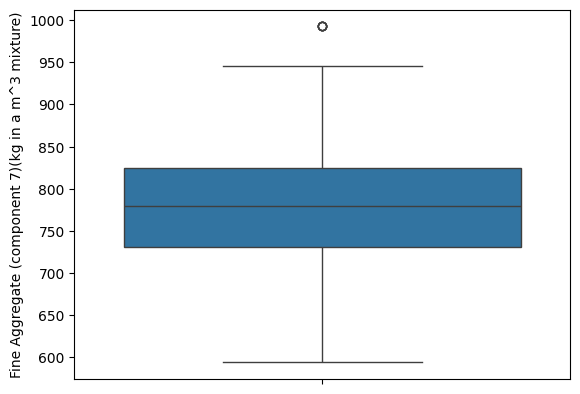

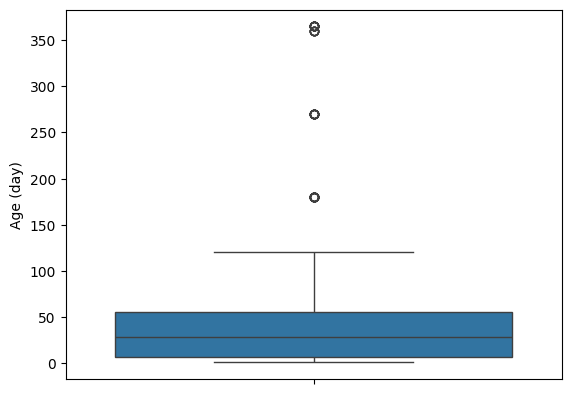

In [79]:
for col in features:
    sns.boxplot(df[col])
    plt.show()

Preprocessing

In [ ]:
from sklearn.model_selection import train_test_split

X_list = []
X_list = df[features]
y = df["Concrete compressive strength(MPa, megapascals) "]
ts = 0.2 #bagian ini kalian modify la sesuai user mau di berapa
rs = 42 #bagian ini juga bebas user mau modify gmn

X_train, X_test, y_train, y_test = train_test_split(X_list, y, test_size=ts, random_state=rs)

nnti kasi opsi lagi mau standard scaler apa normalization

In [81]:
#ini kalau mau standard scaler
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [82]:
#ini kalau mau minmax scaler
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()
X_train = mm.fit_transform(X_train)
X_test = mm.transform(X_test)

In [83]:
MainModel = None

In [84]:
#model 1, linreg
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
model_lr = lr.fit(X_train, y_train)

In [85]:
#model 2, randomForestRegressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
model_rf = rf.fit(X_train, y_train)

In [86]:
#model 3, SVR(Support vector regression)
from sklearn.svm import SVR

svr = SVR()
model_svr = svr.fit(X_train, y_train)

In [87]:
#suru choose model, nanti dimasukkin modelnya ke MainModel
import pickle
#misal disini kita ngambil model_rf
MainModel = model_rf
with open("MainModel.pkl", "wb") as file:
    pickle.dump(MainModel, file)


In [89]:
#Ini kalau mau load model
with open("MainModel.pkl", "rb") as file:
    loaded_model = pickle.load(file)

y_pred = loaded_model.predict(X_test)


In [90]:
#bagian evaluation
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("Evaluation Metrics")
print("R2 Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("MSE      :", mean_squared_error(y_test, y_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred)))

Evaluation Metrics
R2 Score : 0.8781652714904089
MAE      : 3.873030743353202
MSE      : 31.394505409964893
RMSE     : 5.603079993179188
